# AIRPATH-AI Milestone 3B — road network and segment ETA

This notebook reproduces the bounded OpenStreetMap route/ETA example.

Scope safeguards:

- routes remain inside the HealthyAir stations 2–6 support polygon;
- supported modes are walking and motorbike only;
- travel time uses explicit constant speeds, not traffic prediction;
- candidate routes are not ranked by PM2.5;
- no spatial estimator or exposure calculation is called;
- exact segment ETAs do not imply minute-level PM2.5 support.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.eta_engine import DEFAULT_MODE_SPEED_KMH
from src.road_network import load_network, road_type_counts
from src.route_candidates import generate_milestone_outputs

In [2]:
network_path = PROJECT_ROOT / "data/processed/road_network/healthyair_pilot_osm.json.gz"
network = load_network(network_path)

{
    "requested_snapshot_date": network.metadata["requested_snapshot_date"],
    "overpass_server_base_timestamp": network.metadata["osm_snapshot_timestamp"],
    "filter_rule_version": network.metadata["filter_rule_version"],
    "all_nodes": len(network.nodes),
    "all_directed_edges": len(network.edges),
    "walking": network.mode_counts("walking"),
    "walking_routing_component": network.routing_component_counts("walking"),
    "motorbike": network.mode_counts("motorbike"),
    "motorbike_routing_component": network.routing_component_counts("motorbike"),
    "speed_assumptions_kmh": DEFAULT_MODE_SPEED_KMH,
}

{'requested_snapshot_date': '2026-08-20T07:56:51Z',
 'overpass_server_base_timestamp': '2026-08-20T08:08:01Z',
 'filter_rule_version': 'airpath-osm-filter-v2',
 'all_nodes': 62463,
 'all_directed_edges': 141161,
 'walking': {'nodes': 62401, 'directed_edges': 141036},
 'walking_routing_component': {'nodes': 59738, 'directed_edges': 135964},
 'motorbike': {'nodes': 57252, 'directed_edges': 120668},
 'motorbike_routing_component': {'nodes': 55037, 'directed_edges': 116955},
 'speed_assumptions_kmh': {'walking': 5.0, 'motorbike': 25.0}}

In [3]:
outputs = generate_milestone_outputs(
    network_path,
    processed_directory=PROJECT_ROOT / "data/processed/road_network",
    report_root=PROJECT_ROOT / "reports",
    k=5,
)
outputs["route_summary"]

,route_id,mode,edge_count,total_distance_m,total_travel_time_seconds,origin_snap_distance_m,destination_snap_distance_m
0,walking-1,walking,121,3882.403577,2795.330575,21.262299,88.786337
1,walking-2,walking,120,3882.719899,2795.558327,21.262299,88.786337
2,walking-3,walking,120,3883.703751,2796.266701,21.262299,88.786337
3,walking-4,walking,119,3884.020073,2796.494452,21.262299,88.786337
4,walking-5,walking,121,3884.209832,2796.631079,21.262299,88.786337
5,motorbike-1,motorbike,133,3869.319300,557.181979,21.262299,88.786337
6,motorbike-2,motorbike,130,3872.513760,557.641981,21.262299,88.786337
7,motorbike-3,motorbike,129,3877.145954,558.309017,21.262299,88.786337
8,motorbike-4,motorbike,126,3880.340413,558.769019,21.262299,88.786337
9,motorbike-5,motorbike,120,3883.703751,559.253340,21.262299,88.786337


In [4]:
motorbike_segments = outputs["segment_table"].loc[
    outputs["segment_table"]["route_id"].eq("motorbike-1")
]
display(motorbike_segments.head(8))
display(motorbike_segments.tail(2))

# This is the future route-to-spatial contract only. It is not passed to
# estimate_pm25 during Milestone 3B.
outputs["spatial_targets"][:3]

,route_id,segment_index,edge_id,start_node,end_node,road_type,direction,mode,segment_geometry,representative_latitude,representative_longitude,segment_duration_seconds,entry_elapsed_seconds,cumulative_elapsed_seconds,entry_timestamp,target_arrival_timestamp,estimated_arrival_timestamp
601,motorbike-1,1,242307850:0:f,2498079018,2498079021,service,forward,motorbike,"[[10.7802867, 106.6595074], [10.7813987, 106.6...",10.780843,106.660043,24.510766,0.000000,24.510766,2026-08-20T08:00:00+07:00,2026-08-20T08:00:12.255383185+07:00,2026-08-20T08:00:24.510766371+07:00
602,motorbike-1,2,242307850:1:f,2498079021,366433075,service,forward,motorbike,"[[10.7813987, 106.6605783], [10.7807714, 106.6...",10.781085,106.660655,10.329037,24.510766,34.839803,2026-08-20T08:00:24.510766371+07:00,2026-08-20T08:00:29.675284872+07:00,2026-08-20T08:00:34.839803373+07:00
603,motorbike-1,3,1277704606:0:r,366433075,1349033429,residential,reverse,motorbike,"[[10.7807714, 106.6607314], [10.7810596, 106.6...",10.780916,106.661114,12.877292,34.839803,47.717095,2026-08-20T08:00:34.839803373+07:00,2026-08-20T08:00:41.278449392+07:00,2026-08-20T08:00:47.717095411+07:00
604,motorbike-1,4,520723335:2:r,1349033429,4415686093,tertiary,reverse,motorbike,"[[10.7810596, 106.6614957], [10.7813997, 106.6...",10.781230,106.661932,14.751753,47.717095,62.468848,2026-08-20T08:00:47.717095411+07:00,2026-08-20T08:00:55.092971932+07:00,2026-08-20T08:01:02.468848453+07:00
605,motorbike-1,5,520723335:1:r,4415686093,4415547496,tertiary,reverse,motorbike,"[[10.7813997, 106.6623673], [10.7817477, 106.6...",10.781574,106.662813,15.095189,62.468848,77.564038,2026-08-20T08:01:02.468848453+07:00,2026-08-20T08:01:10.016443017+07:00,2026-08-20T08:01:17.564037582+07:00
606,motorbike-1,6,520723335:0:r,4415547496,366413355,tertiary,reverse,motorbike,"[[10.7817477, 106.6632592], [10.7822562, 106.6...",10.782002,106.663917,22.249526,77.564038,99.813563,2026-08-20T08:01:17.564037582+07:00,2026-08-20T08:01:28.688800346+07:00,2026-08-20T08:01:39.813563110+07:00
607,motorbike-1,7,32579174:7:f,366413355,366382549,residential,forward,motorbike,"[[10.7822562, 106.6645756], [10.7818835, 106.6...",10.782070,106.664890,11.546174,99.813563,111.359737,2026-08-20T08:01:39.813563110+07:00,2026-08-20T08:01:45.586650188+07:00,2026-08-20T08:01:51.359737266+07:00
608,motorbike-1,8,32579174:8:f,366382549,366457844,residential,forward,motorbike,"[[10.7818835, 106.665204], [10.7815821, 106.66...",10.781733,106.665492,10.258391,111.359737,121.618129,2026-08-20T08:01:51.359737266+07:00,2026-08-20T08:01:56.488932993+07:00,2026-08-20T08:02:01.618128720+07:00


,route_id,segment_index,edge_id,start_node,end_node,road_type,direction,mode,segment_geometry,representative_latitude,representative_longitude,segment_duration_seconds,entry_elapsed_seconds,cumulative_elapsed_seconds,entry_timestamp,target_arrival_timestamp,estimated_arrival_timestamp
732,motorbike-1,132,327048054:16:f,5778300433,411926144,tertiary,forward,motorbike,"[[10.777541, 106.6876317], [10.7774802, 106.68...",10.777511,106.687665,1.422068,547.195006,548.617074,2026-08-20T08:09:07.195006098+07:00,2026-08-20T08:09:07.906040021+07:00,2026-08-20T08:09:08.617073944+07:00
733,motorbike-1,133,327048054:17:f,411926144,411926143,tertiary,forward,motorbike,"[[10.7774802, 106.6876976], [10.7771139, 106.6...",10.777297,106.687896,8.564905,548.617074,557.181979,2026-08-20T08:09:08.617073944+07:00,2026-08-20T08:09:12.899526607+07:00,2026-08-20T08:09:17.181979270+07:00


[{'route_id': 'walking-1',
  'segment_index': 1,
  'edge_id': '242307850:0:f',
  'latitude': 10.780842700000001,
  'longitude': 106.66004285,
  'target_time': Timestamp('2026-08-20 08:01:01.276915927+0700', tz='UTC+07:00')},
 {'route_id': 'walking-1',
  'segment_index': 2,
  'edge_id': '242307850:1:f',
  'latitude': 10.781085050000002,
  'longitude': 106.66065485,
  'target_time': Timestamp('2026-08-20 08:02:28.376424359+0700', tz='UTC+07:00')},
 {'route_id': 'walking-1',
  'segment_index': 3,
  'edge_id': '1277704606:0:r',
  'latitude': 10.7809155,
  'longitude': 106.66111355000001,
  'target_time': Timestamp('2026-08-20 08:03:26.392246959+0700', tz='UTC+07:00')}]

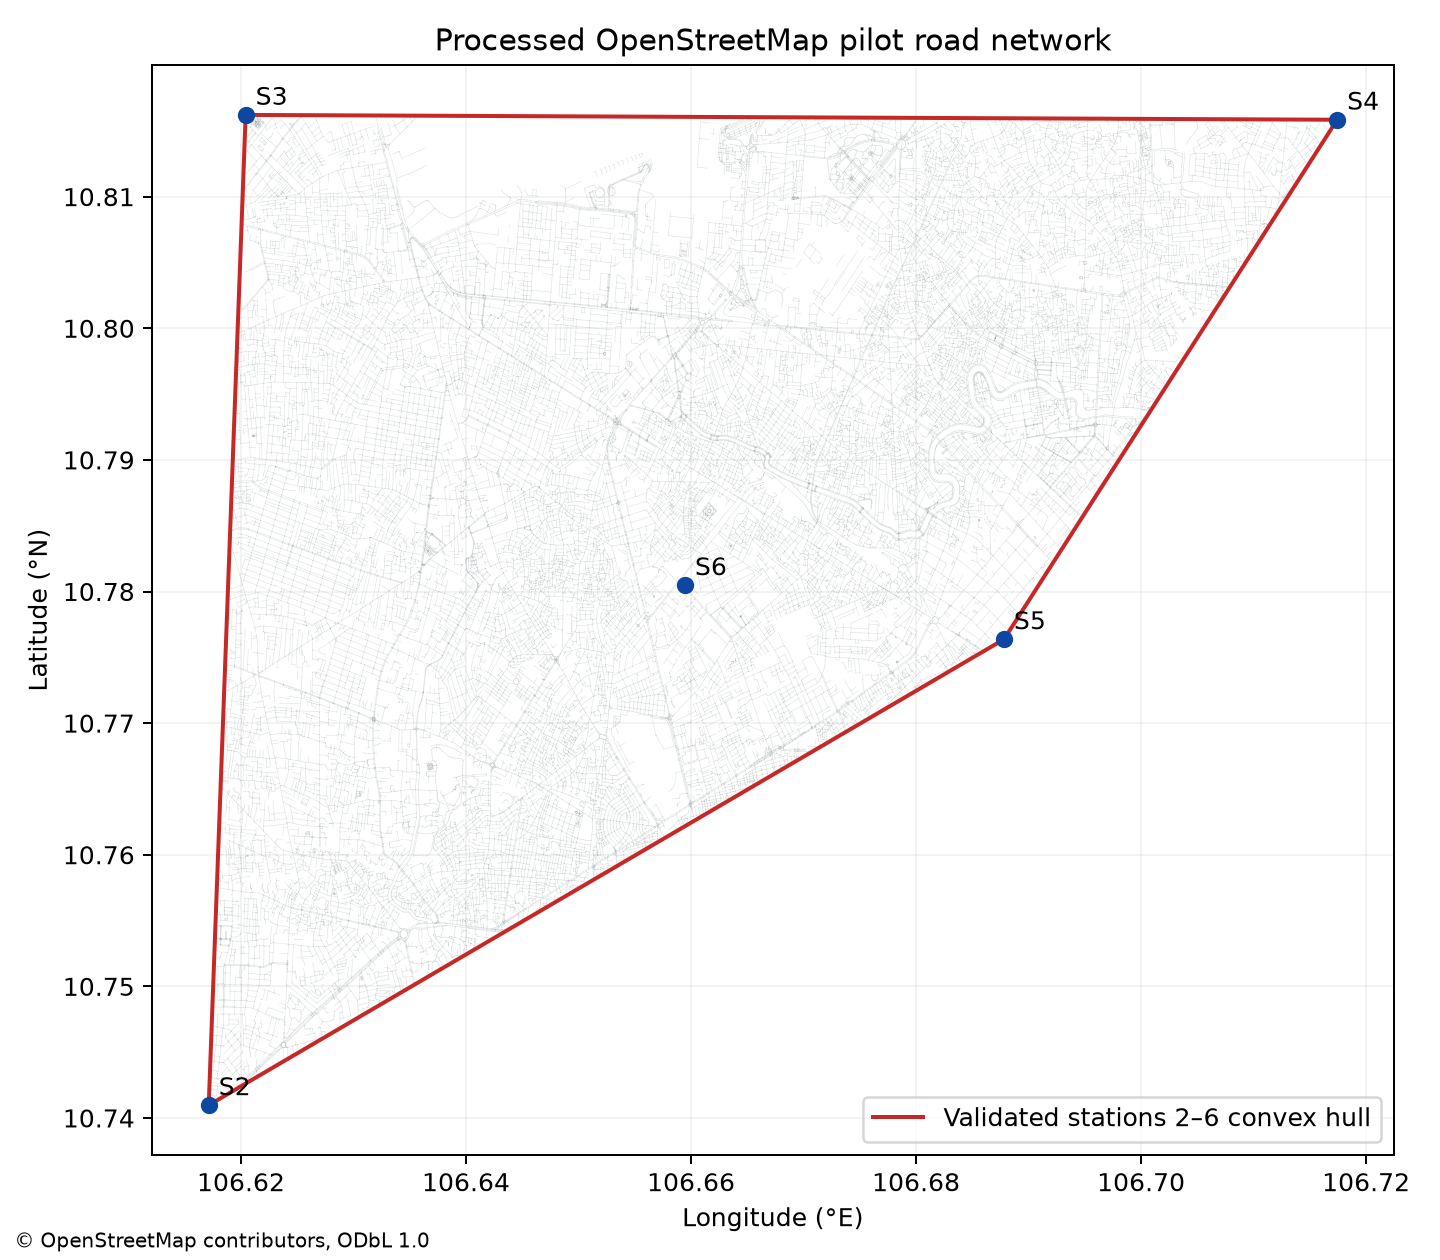

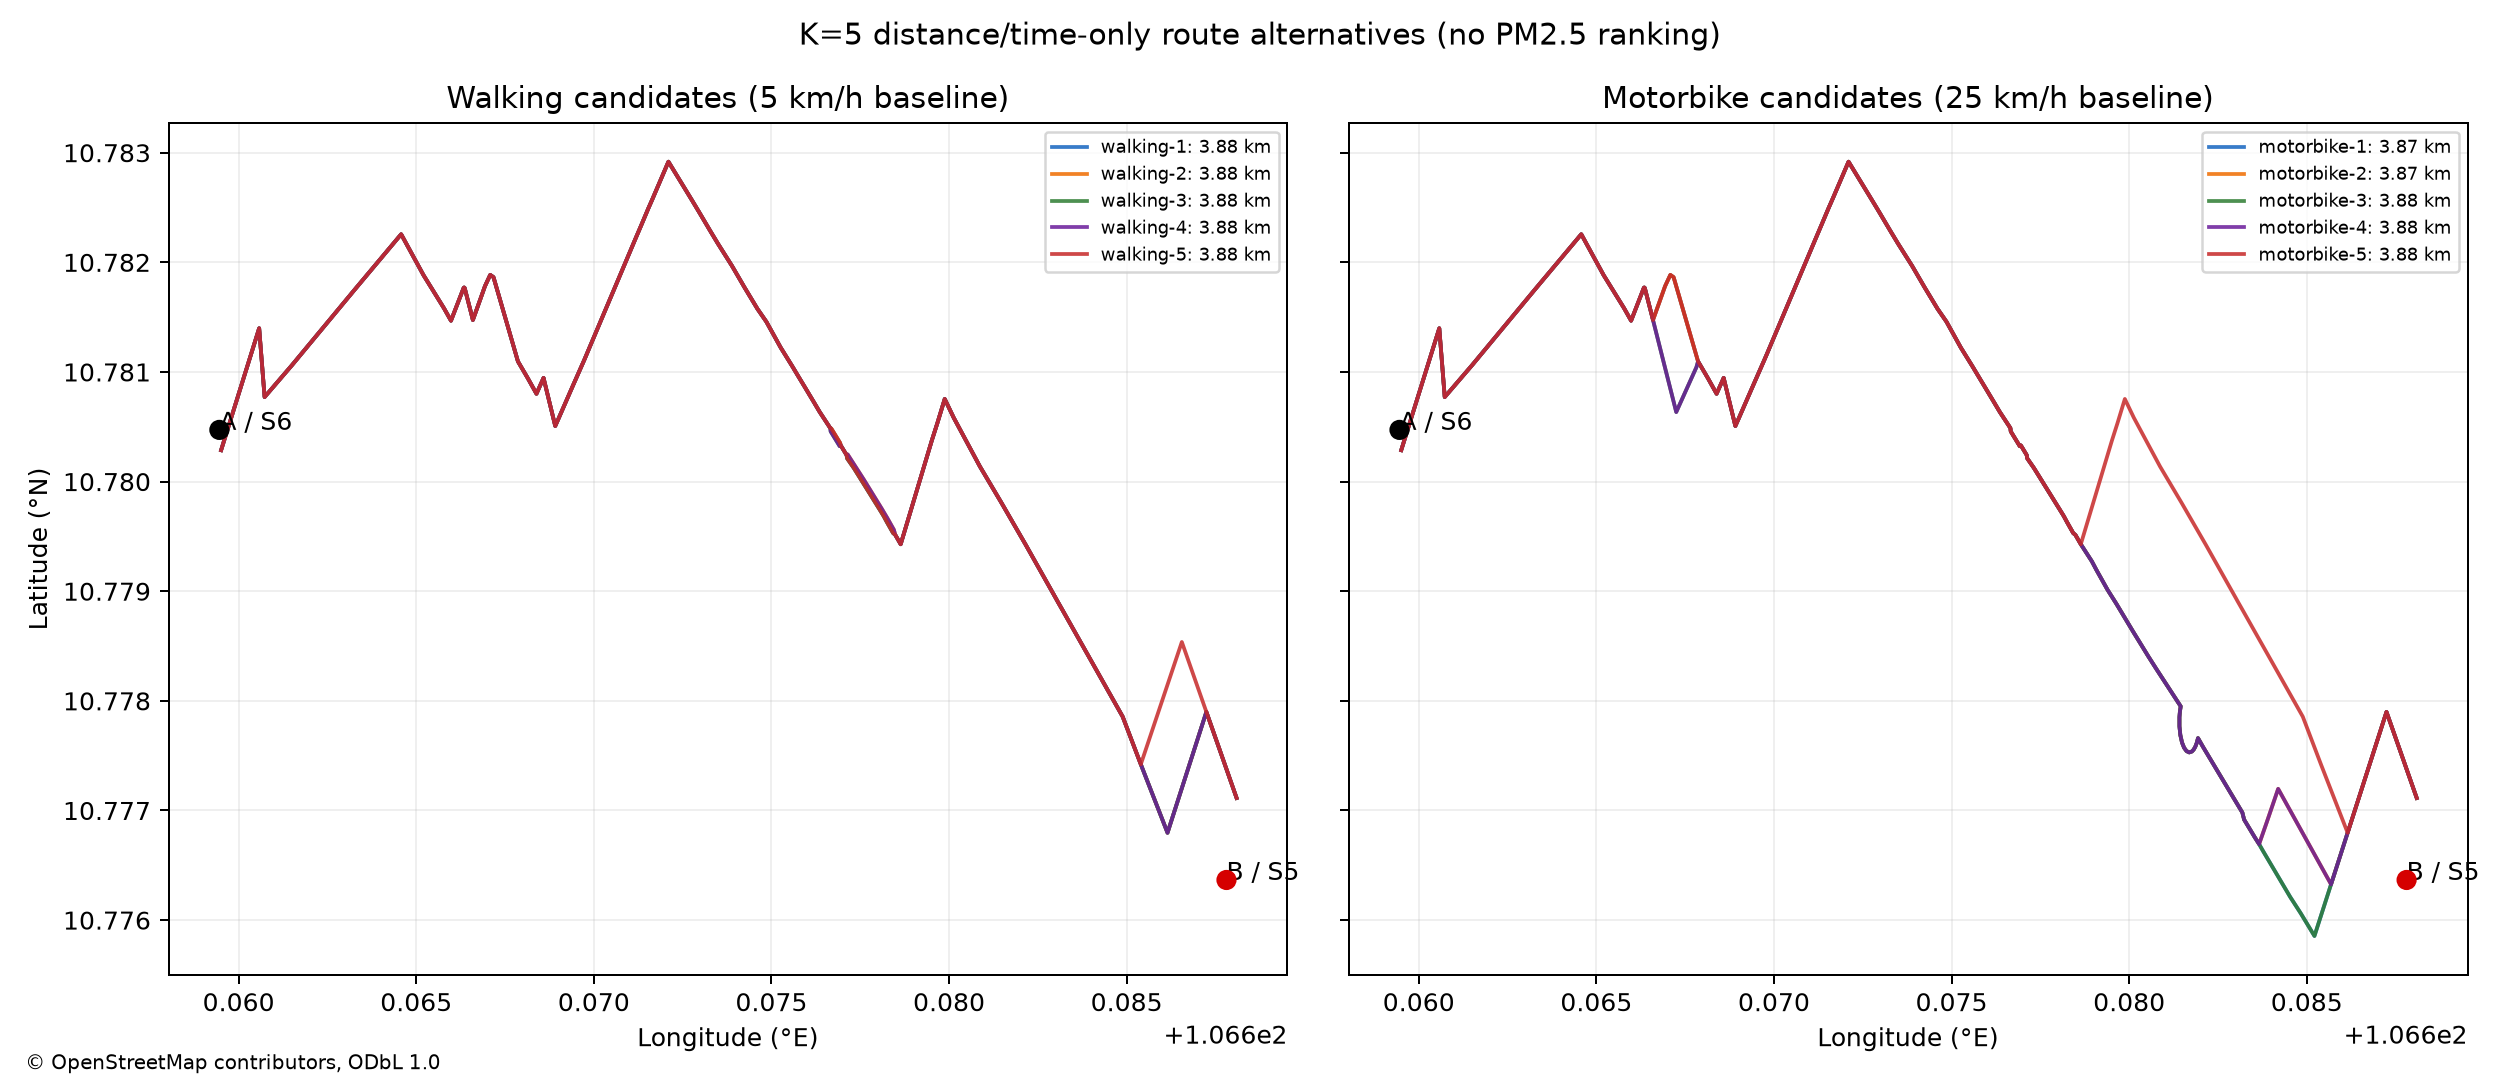

In [5]:
display(Image(filename=PROJECT_ROOT / "reports/figures/road_network_pilot.png"))
display(Image(filename=PROJECT_ROOT / "reports/figures/road_network_candidate_routes.png"))